In [1]:
# --- CELL 1: SETUP MÔI TRƯỜNG ---
import os

print("Đang cài đặt môi trường... (Mất khoảng 1-2 phút)")

# 1. Ép buộc cài Numpy phiên bản cũ để tránh xung đột
!pip install "numpy<2" setuptools==69.5.1 > /dev/null 2>&1

# 2. Clone GFPGAN & Cài đặt
if not os.path.exists('GFPGAN'):
    !git clone https://github.com/TencentARC/GFPGAN.git
    %cd GFPGAN
    # Cài đặt thư viện phụ thuộc
    !pip install basicsr facexlib > /dev/null 2>&1
    !pip install -r requirements.txt > /dev/null 2>&1
    !python setup.py develop > /dev/null 2>&1

    # Tải Model Pre-trained (v1.4 là bản tốt nhất cho da)
    if not os.path.exists('experiments/pretrained_models/GFPGANv1.4.pth'):
        !wget https://github.com/TencentARC/GFPGAN/releases/download/v1.3.0/GFPGANv1.4.pth -P experiments/pretrained_models > /dev/null 2>&1
else:
    %cd GFPGAN

# 3. VÁ LỖI TORCHVISION (Auto-Fix)
# Sửa lỗi 'functional_tensor' do Colab cập nhật bản mới
print("🔧 Đang vá lỗi phiên bản thư viện...")
!sed -i 's/from torchvision.transforms.functional_tensor import rgb_to_grayscale/from torchvision.transforms.functional import rgb_to_grayscale/g' /usr/local/lib/python*/dist-packages/basicsr/data/degradations.py

print("✅ Đã cài đặt xong! Hãy chạy Cell tiếp theo.")

Đang cài đặt môi trường... (Mất khoảng 1-2 phút)


The system cannot find the path specified.


c:\Users\63200744\Desktop\AI\FSB\IVP501\practice\assignment\GFPGAN


Cloning into 'GFPGAN'...
The system cannot find the path specified.
The system cannot find the path specified.
The system cannot find the path specified.
The system cannot find the path specified.

🔧 Đang vá lỗi phiên bản thư viện...


✅ Đã cài đặt xong! Hãy chạy Cell tiếp theo.


'sed' is not recognized as an internal or external command,
operable program or batch file.


Đang xử lý ảnh: C:/Users/63200744/Desktop/AI/FSB/IVP501/images/human-face-1.jpg


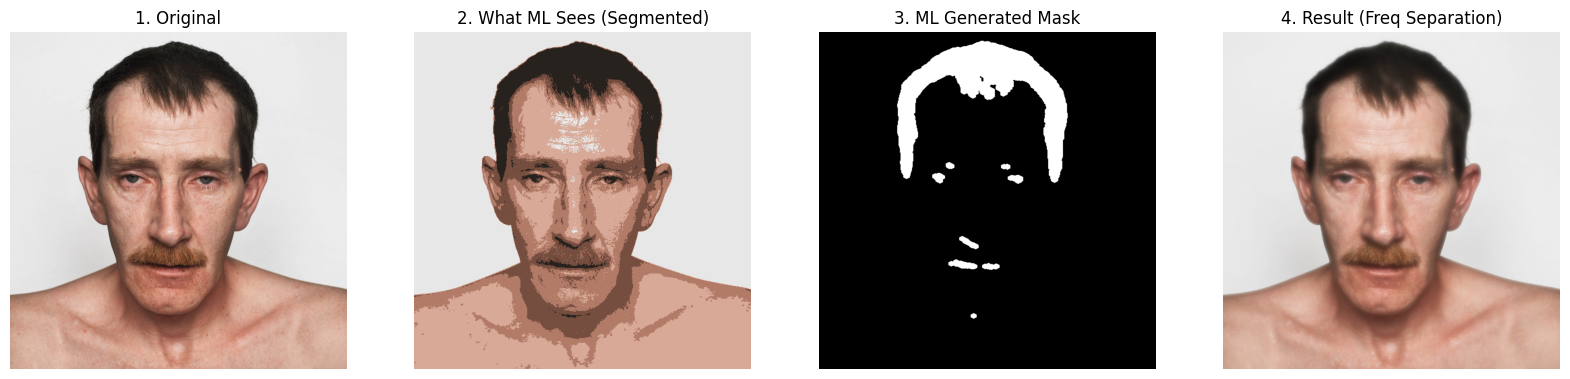

In [4]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import os
import glob

# # --- BƯỚC 1: TÌM ẢNH TỰ ĐỘNG ---
# def get_image_path():
#     possible_files = glob.glob('*.jpg') + glob.glob('data/*.jpg') + glob.glob('*.png') + glob.glob('data/*.png')
#     # Lọc bỏ ảnh kết quả cũ
#     valid_files = [f for f in possible_files if 'result' not in f and 'sample' not in f]

#     if not valid_files:
#         if not os.path.exists('data'): os.makedirs('data')
#         !wget -O data/input.jpg "https://i.imgur.com/uC58y2R.jpeg" > /dev/null 2>&1
#         return 'data/input.jpg'
#     return max(valid_files, key=os.path.getctime)

# --- CLASS XỬ LÝ ẢNH LAI GHÉP (ML + VISUAL COMPUTING) ---
class HybridSkinRetouch:
    def __init__(self, n_clusters=5):
        # Tăng số cluster lên 5 để phân loại màu da chi tiết hơn
        self.k = n_clusters
        self.kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)

    def get_ml_mask(self, img):
        """Dùng ML (K-Means) để bắt vùng mụn"""
        # Resize nhỏ để train nhanh
        small_img = cv2.resize(img, (0,0), fx=0.5, fy=0.5)
        img_lab = cv2.cvtColor(small_img, cv2.COLOR_BGR2LAB)
        features = img_lab.reshape((-1, 3))

        # Train K-Means
        labels = self.kmeans.fit_predict(features)
        centers = self.kmeans.cluster_centers_

        # Logic tìm cụm mụn: Cụm nào Đỏ nhất (a cao) và Tối (L thấp)
        # Score = Redness (a) * 1.5 - Lightness (L)
        scores = centers[:, 1] * 1.5 - centers[:, 0]
        acne_idx = np.argmax(scores)

        # Tạo mask
        mask_small = (labels == acne_idx).reshape(small_img.shape[:2]).astype(np.uint8) * 255

        # Resize mask về kích thước gốc
        mask = cv2.resize(mask_small, (img.shape[1], img.shape[0]), interpolation=cv2.INTER_NEAREST)

        # Làm sạch mask
        kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5,5))
        mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel, iterations=2)
        mask = cv2.dilate(mask, kernel, iterations=2)

        # Làm mềm biên mask để khi sửa không bị khấc
        mask_soft = cv2.GaussianBlur(mask, (21, 21), 0)

        return mask, mask_soft, labels.reshape(small_img.shape[:2]), centers

    def frequency_separation_heal(self, img, mask_soft):
        """
        KỸ THUẬT MỚI: Frequency Separation
        Thay vì tô màu bệt (Inpaint), ta tách lớp để sửa.
        """
        # 1. Tách lớp Low Frequency (Màu sắc + Ánh sáng)
        # Blur mạnh để lấy tone da chung
        low_freq = cv2.GaussianBlur(img, (31, 31), 0)

        # 2. Tách lớp High Frequency (Chi tiết + Mụn sần)
        # High = Original - Low
        high_freq = cv2.subtract(img, low_freq) + 128

        # --- XỬ LÝ LỚP MÀU (LOW FREQ) ---
        # Dùng Bilateral Filter lên lớp Low để làm đều màu vùng mụn nhưng giữ khối
        healed_low = cv2.bilateralFilter(low_freq, 15, 80, 80)

        # Trộn: Chỉ thay thế màu ở vùng Mask Mụn
        mask_f = mask_soft.astype(float) / 255.0
        mask_3ch = np.stack([mask_f]*3, axis=-1)

        final_low = (healed_low * mask_3ch + low_freq * (1 - mask_3ch))

        # --- XỬ LÝ LỚP CHI TIẾT (HIGH FREQ) ---
        # Vùng mụn thì làm phẳng texture (gán về màu xám 128)
        # Giữ lại 20% texture gốc để không bị "nhựa"
        flat_gray = np.full_like(high_freq, 128)
        healed_high = cv2.addWeighted(high_freq, 0.2, flat_gray, 0.8, 0)

        final_high = (healed_high * mask_3ch + high_freq * (1 - mask_3ch))

        # 3. Gộp lại: Result = Low + High - 128
        result = cv2.addWeighted(final_low.astype(np.uint8), 1.0, final_high.astype(np.uint8), 1.0, -128)

        return result

    def run(self, img_path):
        img = cv2.imread(img_path)
        if img is None: return None, None, None, None

        # Resize nếu ảnh quá to
        h, w = img.shape[:2]
        if w > 1000:
            scale = 1000/w
            img = cv2.resize(img, (0,0), fx=scale, fy=scale)

        # 1. Dùng ML để "Bắt bệnh" (Detection)
        mask_hard, mask_soft, labels, centers = self.get_ml_mask(img)

        # Visualize cái mà ML nhìn thấy
        h_small, w_small = labels.shape
        seg_view = centers[labels].reshape((h_small, w_small, 3)).astype(np.uint8)
        seg_view = cv2.cvtColor(seg_view, cv2.COLOR_LAB2BGR) # Convert ngược lại để xem

        # 2. Dùng Frequency Separation để "Chữa bệnh" (Healing)
        result = self.frequency_separation_heal(img, mask_soft)

        return img, seg_view, mask_hard, result

# --- CHẠY ---
img_path = 'C:/Users/63200744/Desktop/AI/FSB/IVP501/images/human-face-1.jpg'
print(f"Đang xử lý ảnh: {img_path}")

processor = HybridSkinRetouch(n_clusters=5)
orig, ml_view, mask, res = processor.run(img_path)

if orig is not None:
    plt.figure(figsize=(20, 10))

    plt.subplot(1, 4, 1)
    plt.imshow(cv2.cvtColor(orig, cv2.COLOR_BGR2RGB))
    plt.title("1. Original")
    plt.axis('off')

    plt.subplot(1, 4, 2)
    plt.imshow(cv2.cvtColor(ml_view, cv2.COLOR_BGR2RGB))
    plt.title("2. What ML Sees (Segmented)")
    plt.axis('off')

    plt.subplot(1, 4, 3)
    plt.imshow(mask, cmap='gray')
    plt.title("3. ML Generated Mask")
    plt.axis('off')

    plt.subplot(1, 4, 4)
    plt.imshow(cv2.cvtColor(res, cv2.COLOR_BGR2RGB))
    plt.title("4. Result (Freq Separation)")
    plt.axis('off')

    plt.show()
else:
    print("Lỗi đọc ảnh.")

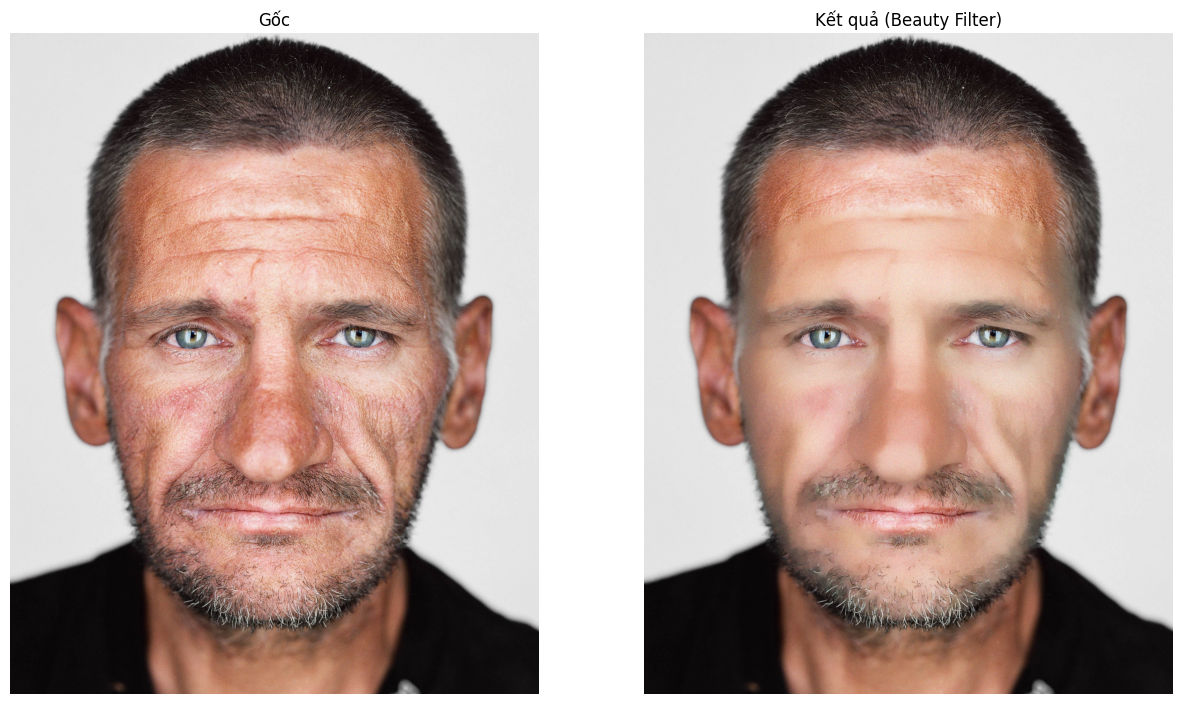

In [7]:
import cv2
import numpy as np
import mediapipe as mp
import matplotlib.pyplot as plt
import os
import glob

# --- TỰ ĐỘNG TÌM ẢNH ---
def get_image_path():
    possible_files = glob.glob('*.jpg') + glob.glob('data/*.jpg') + glob.glob('*.png') + glob.glob('data/*.png')
    valid_files = [f for f in possible_files if 'result' not in f and 'sample' not in f]
    if not valid_files:
        if not os.path.exists('data'): os.makedirs('data')
        !wget -O data/input.jpg "https://i.imgur.com/uC58y2R.jpeg" > /dev/null 2>&1
        return 'data/input.jpg'
    return max(valid_files, key=os.path.getctime)

class UltimateBeautyCam:
    def __init__(self):
        self.mp_face_mesh = mp.solutions.face_mesh
        self.face_mesh = self.mp_face_mesh.FaceMesh(static_image_mode=True, max_num_faces=1, refine_landmarks=True)

    def get_face_mask(self, img):
        """Tạo mask da mặt cực chuẩn, loại bỏ mắt/môi"""
        h, w = img.shape[:2]
        mask = np.zeros((h, w), dtype=np.uint8)

        results = self.face_mesh.process(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        if not results.multi_face_landmarks: return None

        landmarks = results.multi_face_landmarks[0].landmark

        # 1. Lấy toàn bộ khuôn mặt
        face_oval = [10, 338, 297, 332, 284, 251, 389, 356, 454, 323, 361, 288, 397, 365, 379, 378, 400, 377, 152, 148, 176, 149, 150, 136, 172, 58, 132, 93, 234, 127, 162, 21, 54, 103, 67, 109]
        pts = np.array([(int(landmarks[i].x * w), int(landmarks[i].y * h)) for i in face_oval])
        cv2.fillPoly(mask, [pts], 255)

        # 2. Trừ bỏ Mắt & Môi (Giữ nét)
        eyes_lips = [
            [362, 382, 381, 380, 374, 373, 390, 249, 263, 466, 388, 387, 386, 385, 384, 398], # Trái
            [33, 7, 163, 144, 145, 153, 154, 155, 133, 173, 157, 158, 159, 160, 161, 246],   # Phải
            [61, 146, 91, 181, 84, 17, 314, 405, 321, 375, 291, 409, 270, 269, 267, 0, 267], # Môi
            [55, 65, 52, 53, 46], # Lông mày trái (sơ bộ)
            [285, 295, 282, 283, 276] # Lông mày phải
        ]
        for parts in eyes_lips:
            pts = np.array([(int(landmarks[i].x * w), int(landmarks[i].y * h)) for i in parts])
            cv2.fillPoly(mask, [pts], 0) # Tô đen để bảo vệ

        # Làm mềm biên mask để không bị viền cứng
        mask = cv2.GaussianBlur(mask, (31, 31), 0)
        return mask

    def skin_smoothing_strong(self, img):
        """Thuật toán Domain Transform (Mạnh nhất của OpenCV)"""
        # Đây là thuật toán chuyên dụng để làm mịn da trong các app chỉnh ảnh
        # sigma_s: Độ làm mờ không gian (càng cao càng phẳng)
        # sigma_r: Độ giữ cạnh (càng thấp càng giữ nét mắt mũi)

        # Lần 1: Xóa mụn to
        smooth = cv2.edgePreservingFilter(img, flags=1, sigma_s=50, sigma_r=0.4)
        # Lần 2: Làm mịn bề mặt
        smooth = cv2.edgePreservingFilter(smooth, flags=1, sigma_s=40, sigma_r=0.3)

        return smooth

    def add_grain(self, img):
        """Thêm hạt nhiễu giả lập da thật (Tránh da nhựa)"""
        h, w, c = img.shape
        noise = np.random.randn(h, w, c) * 10 # Cường độ hạt
        noisy_img = img.astype(float) + noise
        return np.clip(noisy_img, 0, 255).astype(np.uint8)

    def color_grading(self, img):
        """Chỉnh màu trắng hồng"""
        # Tăng sáng
        lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
        l, a, b = cv2.split(lab)

        # Kéo curve sáng lên (Gamma correction)
        l = cv2.add(l, 10)

        # Giảm đỏ (a), Tăng hồng (b chút xíu)
        a = cv2.add(a, -5)

        merged = cv2.merge((l, a, b))
        return cv2.cvtColor(merged, cv2.COLOR_LAB2BGR)

    def run(self, img_path):
        img = cv2.imread(img_path)
        if img is None: return None, None

        h, w = img.shape[:2]
        if w > 1200: img = cv2.resize(img, (0,0), fx=1200/w, fy=1200/w)

        # 1. Tạo mask da
        mask_gray = self.get_face_mask(img)
        mask_3ch = cv2.cvtColor(mask_gray, cv2.COLOR_GRAY2BGR) / 255.0

        # 2. Tạo lớp da mới (Mịn + Hạt + Sáng)
        skin_layer = self.skin_smoothing_strong(img)
        skin_layer = self.color_grading(skin_layer)
        skin_layer = self.add_grain(skin_layer)

        # 3. Trộn (Blending)
        # 70% Da mới + 30% Da cũ (để giữ chút tự nhiên)
        final = (skin_layer * mask_3ch + img * (1 - mask_3ch)).astype(np.uint8)

        # Blend thêm một lớp ảnh gốc nhẹ nữa (15%) để lấy lại texture thật
        final = cv2.addWeighted(final, 0.85, img, 0.15, 0)

        return img, final

# --- CHẠY ---
img_path = 'C:/Users/63200744/Desktop/AI/FSB/IVP501/images/MS_Michael_Homeless.jpg'
processor = UltimateBeautyCam()
orig, res = processor.run(img_path)

if orig is not None:
    plt.figure(figsize=(15, 10))
    plt.subplot(1, 2, 1); plt.imshow(cv2.cvtColor(orig, cv2.COLOR_BGR2RGB)); plt.title("Gốc")
    plt.axis('off')
    plt.subplot(1, 2, 2); plt.imshow(cv2.cvtColor(res, cv2.COLOR_BGR2RGB)); plt.title("Kết quả (Beauty Filter)")
    plt.axis('off')
    plt.show()